In [ ]:
# ── 1. Drive bağla ───────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── 2. Zip'i aç ──────────────────────────────────────────
import zipfile, os

ZIP_PATH    = "/content/drive/MyDrive/dataset/food101.zip"
EXTRACT_DIR = "/content/food101"

print("Zip açılıyor...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print("Tamamlandı!")

# Yapıyı kontrol et
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/ ({len(files)} files)")
    if level > 2:
        break

Mounted at /content/drive
Zip açılıyor...
Tamamlandı!
food101/ (0 files)
  food101/ (1 files)
    tuna_tartare/ (1000 files)
    pho/ (1000 files)
    risotto/ (1000 files)
    macarons/ (1000 files)
    grilled_salmon/ (1000 files)
    seaweed_salad/ (1000 files)
    miso_soup/ (1000 files)
    escargots/ (1000 files)
    oysters/ (1000 files)
    hummus/ (1000 files)
    bruschetta/ (1000 files)
    nachos/ (1000 files)
    peking_duck/ (1000 files)
    takoyaki/ (1000 files)
    carrot_cake/ (1000 files)
    pancakes/ (1000 files)
    fried_rice/ (1000 files)
    prime_rib/ (1000 files)
    gyoza/ (1000 files)
    french_toast/ (1000 files)
    spring_rolls/ (1000 files)
    cheesecake/ (1000 files)
    pizza/ (1000 files)
    frozen_yogurt/ (1000 files)
    cannoli/ (1000 files)
    bibimbap/ (1000 files)
    grilled_cheese_sandwich/ (1000 files)
    tacos/ (1000 files)
    crab_cakes/ (1000 files)
    chicken_wings/ (1000 files)
    ceviche/ (1000 files)
    panna_cotta/ (1000 fil

In [ ]:
# Turkish Foods dataset'ini HF'ten indir
from huggingface_hub import snapshot_download

print("TurkishFoods-25 indiriliyor...")
snapshot_download(
    repo_id="yunusserhat/TurkishFoods-25",
    repo_type="dataset",
    local_dir="/content/turkish_foods"
)
print("Tamamlandı!")

# Yapıyı kontrol et
import os
for root, dirs, files in os.walk("/content/turkish_foods"):
    level = root.replace("/content/turkish_foods", '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/ ({len(files)} files)")
    if level > 2:
        break

TurkishFoods-25 indiriliyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Tamamlandı!
turkish_foods/ (2 files)
  .cache/ (0 files)
    huggingface/ (2 files)
      download/ (2 files)


In [ ]:
import os

for root, dirs, files in os.walk("/content/turkish_foods"):
    level = root.replace("/content/turkish_foods", '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/ ({len(files)} files)")
    for f in files[:5]:
        print(' ' * 2 * (level+1) + f)
    if level > 4:
        break

turkish_foods/ (2 files)
  .gitattributes
  README.md
  .cache/ (0 files)
    huggingface/ (2 files)
      .gitignore
      CACHEDIR.TAG
      download/ (2 files)
        .gitattributes.metadata
        README.md.metadata
        data/ (3 files)
          eval-00000-of-00001.parquet.metadata
          train-00000-of-00001.parquet.metadata
          test-00000-of-00001.parquet.metadata
  data/ (3 files)
    train-00000-of-00001.parquet
    test-00000-of-00001.parquet
    eval-00000-of-00001.parquet


In [ ]:
import pandas as pd
from PIL import Image
import io
import os

TURKISH_OUTPUT = "/content/turkish_foods_images"

for split in ["train", "eval", "test"]:
    parquet_file = f"/content/turkish_foods/data/{split}-00000-of-00001.parquet"
    df = pd.read_parquet(parquet_file)

    print(f"{split} — sütunlar: {df.columns.tolist()}")
    print(f"{split} — satır sayısı: {len(df)}")
    print(f"{split} — sınıflar: {df['label'].unique() if 'label' in df.columns else 'yok'}")
    print()

train — sütunlar: ['image', 'label']
train — satır sayısı: 9168
train — sınıflar: [ 7 21  1  3 14  8 16 13 19 18 22  4 20 15 24  5  6  2 23 10 12 11  9 17
  0]

eval — sütunlar: ['image', 'label']
eval — satır sayısı: 1146
eval — sınıflar: [19  5  4  9 23  3 10 16  1 14  2  7 12 11 17 15 22 21 13 20 24  8  6  0
 18]

test — sütunlar: ['image', 'label']
test — satır sayısı: 1147
test — sınıflar: [ 3  6 12 13 16 21  1  8 14 17 18 10  5  9  7 15 19  0 11  4  2 23 20 22
 24]



In [ ]:
import pandas as pd
from PIL import Image
import io
import os

TURKISH_OUTPUT = "/content/turkish_foods_images"

LABEL_NAMES = {
    0: "asure", 1: "baklava", 2: "biber_dolmasi", 3: "borek", 4: "cig_kofte",
    5: "enginar", 6: "et_sote", 7: "gozleme", 8: "hamsi", 9: "hunkar_begendi",
    10: "icli_kofte", 11: "ispanak", 12: "izmir_kofte", 13: "karniyarik", 14: "kebap",
    15: "kisir", 16: "kuru_fasulye", 17: "lahmacun", 18: "lokum", 19: "manti",
    20: "mucver", 21: "pirinc_pilavi", 22: "simit", 23: "taze_fasulye", 24: "yaprak_sarma"
}

SPLIT_MAP = {"train": "train", "eval": "val", "test": "test"}

for parquet_split, folder_split in SPLIT_MAP.items():
    parquet_file = f"/content/turkish_foods/data/{parquet_split}-00000-of-00001.parquet"
    df = pd.read_parquet(parquet_file)

    print(f"{parquet_split} işleniyor... ({len(df)} görüntü)")

    for idx, row in df.iterrows():
        label_idx  = int(row["label"])
        label_name = LABEL_NAMES[label_idx]

        out_dir = os.path.join(TURKISH_OUTPUT, folder_split, label_name)
        os.makedirs(out_dir, exist_ok=True)

        img_data = row["image"]
        if isinstance(img_data, dict) and "bytes" in img_data:
            img = Image.open(io.BytesIO(img_data["bytes"])).convert("RGB")
        elif isinstance(img_data, bytes):
            img = Image.open(io.BytesIO(img_data)).convert("RGB")
        else:
            continue

        img.save(os.path.join(out_dir, f"{label_name}_{idx}.jpg"))

    print(f"{folder_split} tamamlandı!")

print("\nTüm görüntüler kaydedildi!")
for split in ["train", "val", "test"]:
    total = sum(
        len(os.listdir(os.path.join(TURKISH_OUTPUT, split, c)))
        for c in os.listdir(os.path.join(TURKISH_OUTPUT, split))
    )
    print(f"{split}: {total} görüntü")

train işleniyor... (9168 görüntü)
train tamamlandı!
eval işleniyor... (1146 görüntü)
val tamamlandı!
test işleniyor... (1147 görüntü)
test tamamlandı!

Tüm görüntüler kaydedildi!
train: 9168 görüntü
val: 1146 görüntü
test: 1147 görüntü


In [ ]:
import os
import shutil
import random

# ── Food-101 30 sınıf ────────────────────────────────────
SELECTED_CLASSES = [
    "baklava", "chocolate_cake", "club_sandwich", "donuts", "dumplings",
    "eggs_benedict", "french_fries", "french_toast", "garlic_bread", "gnocchi",
    "grilled_cheese_sandwich", "hamburger", "hot_dog", "ice_cream", "lasagna",
    "miso_soup", "nachos", "omelette", "pad_thai", "pancakes",
    "pizza", "ramen", "ravioli", "risotto", "spaghetti_bolognese",
    "spaghetti_carbonara", "spring_rolls", "sushi", "tiramisu", "waffles",
]

# baklava ikisinde de var — Food-101'dekini çıkar, Turkish'tekini kullan
SELECTED_CLASSES = [c for c in SELECTED_CLASSES if c != "baklava"]
# 29 Food-101 + 25 Turkish = 54 sınıf

SOURCE_DIR = "/content/food101/food101"
OUTPUT_DIR = "/content/combined_dataset"
TURKISH_DIR = "/content/turkish_foods_images"

SPLITS = {"train": 750, "val": 150, "test": 100}
random.seed(42)

# ── Food-101 sınıflarını kopyala ─────────────────────────
print("Food-101 sınıfları kopyalanıyor...")
for cls in SELECTED_CLASSES:
    src = os.path.join(SOURCE_DIR, cls)
    images = [f for f in os.listdir(src) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)

    idx = 0
    for split, count in SPLITS.items():
        dst = os.path.join(OUTPUT_DIR, split, cls)
        os.makedirs(dst, exist_ok=True)
        for img in images[idx:idx+count]:
            shutil.copy(os.path.join(src, img), os.path.join(dst, img))
        idx += count

print("Food-101 tamamlandı!")

# ── Turkish Foods sınıflarını kopyala ────────────────────
print("Turkish Foods kopyalanıyor...")
for split in ["train", "val", "test"]:
    turkish_split = split
    src_split = os.path.join(TURKISH_DIR, turkish_split)

    for cls in os.listdir(src_split):
        src = os.path.join(src_split, cls)
        dst = os.path.join(OUTPUT_DIR, split, cls)
        os.makedirs(dst, exist_ok=True)
        for img in os.listdir(src):
            shutil.copy(os.path.join(src, img), os.path.join(dst, img))

print("Turkish Foods tamamlandı!")

# ── Özet ─────────────────────────────────────────────────
print("\n── Dataset Özeti ──")
for split in ["train", "val", "test"]:
    classes = os.listdir(os.path.join(OUTPUT_DIR, split))
    total = sum(
        len(os.listdir(os.path.join(OUTPUT_DIR, split, c)))
        for c in classes
    )
    print(f"{split}: {len(classes)} sınıf, {total} görüntü")

Food-101 sınıfları kopyalanıyor...
Food-101 tamamlandı!
Turkish Foods kopyalanıyor...
Turkish Foods tamamlandı!

── Dataset Özeti ──
train: 54 sınıf, 30918 görüntü
val: 54 sınıf, 5496 görüntü
test: 54 sınıf, 4047 görüntü


Device: cuda
Sınıflar (54): ['asure', 'baklava', 'biber_dolmasi', 'borek', 'chocolate_cake', 'cig_kofte', 'club_sandwich', 'donuts', 'dumplings', 'eggs_benedict', 'enginar', 'et_sote', 'french_fries', 'french_toast', 'garlic_bread', 'gnocchi', 'gozleme', 'grilled_cheese_sandwich', 'hamburger', 'hamsi', 'hot_dog', 'hunkar_begendi', 'ice_cream', 'icli_kofte', 'ispanak', 'izmir_kofte', 'karniyarik', 'kebap', 'kisir', 'kuru_fasulye', 'lahmacun', 'lasagna', 'lokum', 'manti', 'miso_soup', 'mucver', 'nachos', 'omelette', 'pad_thai', 'pancakes', 'pirinc_pilavi', 'pizza', 'ramen', 'ravioli', 'risotto', 'simit', 'spaghetti_bolognese', 'spaghetti_carbonara', 'spring_rolls', 'sushi', 'taze_fasulye', 'tiramisu', 'waffles', 'yaprak_sarma']
Train: 30918 | Val: 5496 | Test: 4047

── Aşama 1: Frozen backbone ──
Epoch 1/5 — loss: 3.3511 | val_loss: 1.9100 | val_acc: 0.5706 | top3: 0.7742
Epoch 2/5 — loss: 2.3133 | val_loss: 1.5182 | val_acc: 0.6226 | top3: 0.8177
Epoch 3/5 — loss: 2.1658 | val_loss: 1.3

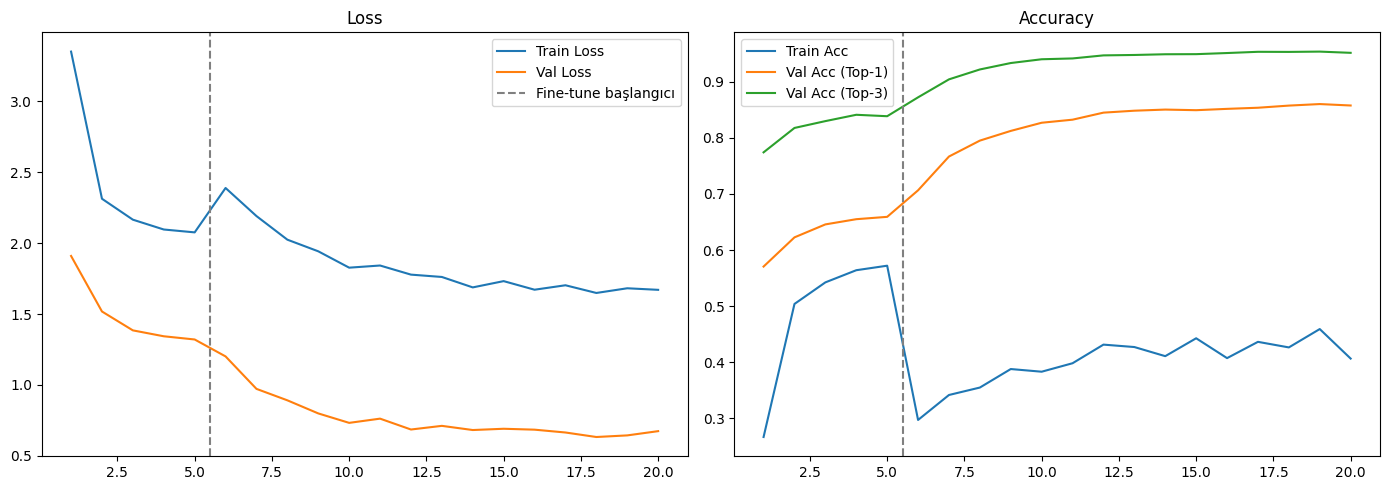

Tamamlandı!


In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import classification_report
from PIL import ImageFile
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

ImageFile.LOAD_TRUNCATED_IMAGES = True

# ── Config ───────────────────────────────────────────────
DATA_DIR      = "/content/combined_dataset"
SAVE_PATH     = "/content/drive/MyDrive/food_model_b2.pth"
BATCH         = 64
EPOCHS_FROZEN = 5
EPOCHS_FT     = 15
LR_FROZEN     = 1e-3
LR_FT         = 3e-4
IMG_SIZE      = 224
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Transforms ───────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1)),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ── Dataset ──────────────────────────────────────────────
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   transform=val_tf)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=val_tf)

print(f"Sınıflar ({len(train_ds.classes)}): {train_ds.classes}")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# ── WeightedRandomSampler ────────────────────────────────
class_counts   = Counter(train_ds.targets)
total          = sum(class_counts.values())
class_weights  = {cls: total / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in train_ds.targets]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)

# ── Model: EfficientNet-B2 ───────────────────────────────
model = models.efficientnet_b2(weights="IMAGENET1K_V1")
for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 512),
    nn.SiLU(),
    nn.Dropout(0.3),
    nn.Linear(512, len(train_ds.classes))
)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Mixup ────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    idx = torch.randperm(x.size(0)).to(DEVICE)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ── Train / Eval ─────────────────────────────────────────
def train_one_epoch(loader, optimizer, scheduler=None, use_mixup=False):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        if use_mixup:
            imgs, y_a, y_b, lam = mixup_data(imgs, labels)
            out  = model(imgs)
            loss = mixup_criterion(criterion, out, y_a, y_b, lam)
        else:
            out  = model(imgs)
            loss = criterion(out, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def evaluate(loader):
    model.eval()
    total_loss, correct = 0, 0
    correct_top3 = 0
    crit = nn.CrossEntropyLoss()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model(imgs)
            loss = crit(out, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            top3 = out.topk(3, dim=1).indices
            for i in range(labels.size(0)):
                if labels[i] in top3[i]:
                    correct_top3 += 1
    n = len(loader.dataset)
    return total_loss / n, correct / n, correct_top3 / n

# ── Aşama 1: Frozen ──────────────────────────────────────
print("\n── Aşama 1: Frozen backbone ──")
optimizer = AdamW(model.classifier.parameters(), lr=LR_FROZEN, weight_decay=1e-4)
scheduler = OneCycleLR(optimizer, max_lr=LR_FROZEN,
                       steps_per_epoch=len(train_loader),
                       epochs=EPOCHS_FROZEN, pct_start=0.3)
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_top3": []}
best_val_acc = 0

for epoch in range(1, EPOCHS_FROZEN + 1):
    tl, ta = train_one_epoch(train_loader, optimizer, scheduler, use_mixup=False)
    vl, va, vt3 = evaluate(val_loader)
    history["train_loss"].append(tl); history["val_loss"].append(vl)
    history["train_acc"].append(ta);  history["val_acc"].append(va)
    history["val_top3"].append(vt3)
    print(f"Epoch {epoch}/{EPOCHS_FROZEN} — loss: {tl:.4f} | val_loss: {vl:.4f} | val_acc: {va:.4f} | top3: {vt3:.4f}")

# ── Aşama 2: Fine-tune ───────────────────────────────────
print("\n── Aşama 2: Fine-tune (Mixup aktif) ──")
for param in model.parameters():
    param.requires_grad = True

optimizer = AdamW([
    {"params": model.features.parameters(),    "lr": LR_FT / 10},
    {"params": model.classifier.parameters(),  "lr": LR_FT},
], weight_decay=1e-4)
scheduler = OneCycleLR(optimizer, max_lr=[LR_FT / 10, LR_FT],
                       steps_per_epoch=len(train_loader),
                       epochs=EPOCHS_FT, pct_start=0.1)

for epoch in range(1, EPOCHS_FT + 1):
    tl, ta = train_one_epoch(train_loader, optimizer, scheduler, use_mixup=True)
    vl, va, vt3 = evaluate(val_loader)
    history["train_loss"].append(tl); history["val_loss"].append(vl)
    history["train_acc"].append(ta);  history["val_acc"].append(va)
    history["val_top3"].append(vt3)
    if va > best_val_acc:
        best_val_acc = va
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_ds.class_to_idx,
            "classes": train_ds.classes,
        }, SAVE_PATH)
        print(f"Epoch {epoch}/{EPOCHS_FT} — loss: {tl:.4f} | val_loss: {vl:.4f} | val_acc: {va:.4f} | top3: {vt3:.4f} ✅ Best!")
    else:
        print(f"Epoch {epoch}/{EPOCHS_FT} — loss: {tl:.4f} | val_loss: {vl:.4f} | val_acc: {va:.4f} | top3: {vt3:.4f}")

print(f"\nEn iyi val_acc: {best_val_acc:.4f}")
print(f"Model kaydedildi: {SAVE_PATH}")

# ── Test ─────────────────────────────────────────────────
print("\n── Test seti ──")
ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
tl, ta, tt3 = evaluate(test_loader)
print(f"Test Top-1: {ta:.4f} | Top-3: {tt3:.4f}")

# ── Grafik ───────────────────────────────────────────────
total_epochs = EPOCHS_FROZEN + EPOCHS_FT
epochs_range = range(1, total_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_range, history["train_loss"], label="Train Loss")
ax1.plot(epochs_range, history["val_loss"],   label="Val Loss")
ax1.axvline(x=EPOCHS_FROZEN + 0.5, color="gray", linestyle="--", label="Fine-tune başlangıcı")
ax1.set_title("Loss"); ax1.legend()
ax2.plot(epochs_range, history["train_acc"], label="Train Acc")
ax2.plot(epochs_range, history["val_acc"],   label="Val Acc (Top-1)")
ax2.plot(epochs_range, history["val_top3"],  label="Val Acc (Top-3)")
ax2.axvline(x=EPOCHS_FROZEN + 0.5, color="gray", linestyle="--")
ax2.set_title("Accuracy"); ax2.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/food_training_curves.png", dpi=150)
plt.show()
print("Tamamlandı!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
